In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from xgboost import XGBRegressor

from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import train_test_split

# Loading cleaned datasets

In [2]:
train = pd.read_csv('train_clean.csv')
test = pd.read_csv('test_clean.csv')
y = pd.read_csv('y.csv').values

In [3]:
train = train.reindex(sorted(train.columns), axis=1).reset_index(drop=True)
test = test.reindex(sorted(train.columns), axis=1).reset_index(drop=True)

In [4]:
def accuracy(y_true,y_pred):
    y_true, y_pred = list(y_true), list(y_pred)
    return np.mean([abs(y_true[i] - y_pred[i]) for i in range(len(y_pred))])

X_train, X_test, y_train, y_test = train_test_split(train, y, test_size=0.2, random_state=28)

# Hyperparameters tuning

In [5]:
xgb_cv =  XGBRegressor(random_state=28)
param_grid_xgb = {
          "objective" : ["reg:squarederror"],
          "max_depth" : [3],
          "subsample" : [0.6],
          "n_estimators" : [26000],
          "learning_rate" : [0.01],
          "eval_metric": ["rmse"],
          "colsample_bytree" : [0.8],
          "colsample_bylevel" : [0.8],
          'colsample_bynode': [0.8],
          "enable_categorical" : [True],
}
xgb_cv = GridSearchCV(xgb_cv, param_grid_xgb, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_cv.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None,...
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=28, ...),
             n_jobs=-1,
             param_grid={'colsample_bylevel': [0.8], 'colsample_bynode': [0.8],
                         'colsample_bytree': [0.8],
                         'enable_categorical': [True], 'eval_metric': ['rmse'],
                         'learning_rate': [0.01], 'max_depth': [3],
                         'n_estimators': [26000],
                         'objective': ['reg:squarederror'],
                         'subsample': [0.6]},
             scoring='neg_mean_squared_error')

In [6]:
print(xgb_cv.best_params_, xgb_cv.best_score_)
print(np.sqrt(-1 * xgb_cv.best_score_))

# Testing on the validation set
y_pred = xgb_cv.predict(X_test)
accuracy(np.exp(y_test), np.exp(y_pred))
# 0.1814, 70131

{'colsample_bylevel': 0.8, 'colsample_bynode': 0.8, 'colsample_bytree': 0.8, 'enable_categorical': True, 'eval_metric': 'rmse', 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 26000, 'objective': 'reg:squarederror', 'subsample': 0.6} -0.032941220447657404
0.18149716374549055


70131.01315917971

# Model training and predictions

In [7]:
xgb =  XGBRegressor(**xgb_cv.best_params_)

In [8]:
xgb.fit(train, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=0.8, colsample_bynode=0.8, colsample_bytree=0.8,
             device=None, early_stopping_rounds=None, enable_categorical=True,
             eval_metric='rmse', feature_types=None, gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=26000, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [9]:
y_pred_xgb = xgb.predict(test)
predictions_e = np.exp(y_pred_xgb).round(2)
print(predictions_e[:5])
np.savetxt("final_submission.txt", predictions_e)
# [ 392915.38 1987135.9  1264279.    404868.2   945402.5 ]

[ 392915.38 1987135.9  1264279.    404868.2   945402.5 ]


# Graphs about features importance / Exploratory Analysis

In [18]:
# Get feature importances
importances = xgb.feature_importances_

# Get feature names
feature_names = X_train.columns

# Create a dictionary mapping feature names to importances
feature_importance_dict = dict(zip(feature_names, importances))

# Sort the dictionary by importance scores in descending order
sorted_feature_importance = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

# Display the top 5 most important features
top_5_features = sorted_feature_importance[:20]
print("Top 20 most important features:")
for feature, importance in top_5_features:
    print(f"{feature}: {importance}")


Top 20 most important features:
bathrooms_number: 0.05072246119379997
square_meters: 0.04003789648413658
zone_baggio: 0.025070881471037865
rooms_number: 0.0204114131629467
zone_carrobbio: 0.020364640280604362
square_meters_error: 0.01572307012975216
zone_quarto_oggiaro: 0.014928322285413742
zone_moscova: 0.014865201897919178
zone_vialba: 0.014012452214956284
zone_brera: 0.013284553773701191
zone_vincenzo_monti: 0.012825771234929562
zone_palestro: 0.01258448138833046
zone_duomo: 0.012280205264687538
zone_roserio: 0.012078684754669666
zone_ticinese: 0.011753015220165253
zone_muggiano: 0.01173760462552309
lift_yes: 0.01140307541936636
zone_ponte_lambro: 0.010989448986947536
conditions_good_condition_/_liveable: 0.010907475836575031
zone_corso_genova: 0.010833016596734524


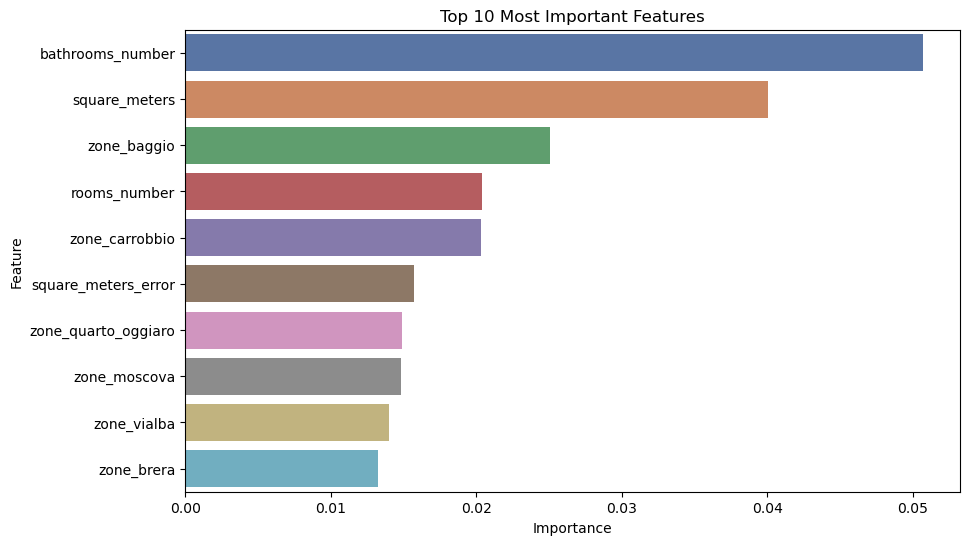

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame from the feature importances
feature_importance_df = pd.DataFrame(sorted_feature_importance, columns=['Feature', 'Importance'])

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='deep')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


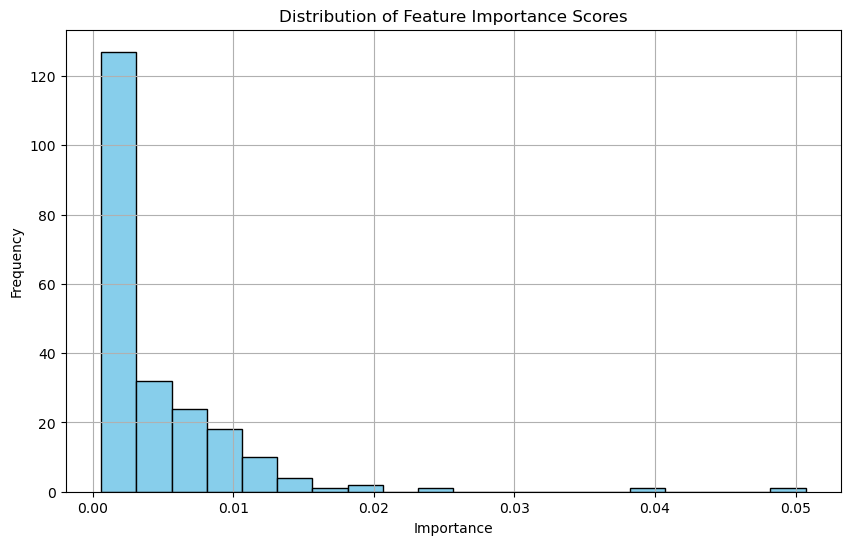

In [14]:
import matplotlib.pyplot as plt

# Plotting histogram
plt.figure(figsize=(10, 6))
plt.hist(feature_importance_df['Importance'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Feature Importance Scores')
plt.xlabel('Importance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
